## **Triple-pendulum model by SREINet**


## **I. Setup and Preprocessing**

In [1]:
# Import os library to access environment variables and operating system functionalities
import os

# Set environment variable to avoid duplicate library errors, specifically for OpenMP
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
# Set TensorFlow log level to '2' to suppress most messages except warnings and errors
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

import sys
sys.path.append("../utilities")

# Import necessary libraries for deep learning and numerical computation
import tensorflow as tf
import numpy as np
from SREINet import * 
import DataGenerator as DG

# Tensowflow version should be 2.13.0 or
# Print a formatted message to the terminal to display current time, date, and TensorFlow version
print("**********************************************")
print("*                                            *")
print("*    Tensorflow Version: " + tf.__version__ + "              *")
print("*                                            *")
print("*******************************|***************")

from packaging import version
if version.parse(tf.__version__) > version.parse('2.10.0'):
    print("Error: Tensorflow version is higher than 2.10. Please use Tensorflow 2.10 or lower.")
    sys.exit()


opt_folder = 'output'
# Create the folder if it doesn't exist
os.makedirs(opt_folder, exist_ok=True)

**********************************************
*                                            *
*    Tensorflow Version: 2.10.0              *
*                                            *
*******************************|***************


### **1.2 Training Data**

In [2]:
def load_triple_pendulum_data(mat_path, downsample=1):
    """
    Loads triple pendulum data from a MATLAB .mat file and returns the relevant arrays, with optional downsampling.
    Args:
        mat_path (str): Path to the .mat file.
        downsample (int): Take every nth sample (default 1, i.e., no downsampling)
    Returns:
        my_data (np.ndarray): Concatenated array of [theta1, theta2, theta3, d_theta1, d_theta2, d_theta3], shape (N, 6)
        d_theta (np.ndarray): Concatenated array of [d_theta1, d_theta2, d_theta3], shape (N, 3)
        time (np.ndarray): Time array
        dt (float): Time step
    """
    from scipy.io import loadmat
    import numpy as np

    data = loadmat(mat_path)
    theta1 = data['Theta1'][::downsample]
    theta2 = data['Theta2'][::downsample]
    theta3 = data['Theta3'][::downsample]
    d_theta1 = data['dTheta1'][::downsample]
    d_theta2 = data['dTheta2'][::downsample]
    d_theta3 = data['dTheta3'][::downsample]

    my_data = np.concatenate([theta1, theta2, theta3, d_theta1, d_theta2, d_theta3], axis=1)
    d_theta = np.concatenate([d_theta1, d_theta2, d_theta3], axis=1)

    return my_data, d_theta

#### Create dataset

In [3]:
# Specify the model type
MY_DATA_TYPE = 'float32'

SEED = 42  # set seed for random number generation
np.random.seed(SEED)

import scipy.io as sio
import numpy as np
from skimage.transform import resize
import matplotlib.pyplot as plt
import cmocean

from sklearn.preprocessing import MinMaxScaler

from scipy.signal import savgol_filter


#load data
from scipy.io import loadmat


data_1, d_theta_1 = load_triple_pendulum_data('../experiment_data/TriplePendulum_Data/TripleDataFreeSwing_1_Dt_0_0001.mat',downsample=100)
data_2, d_theta_2 = load_triple_pendulum_data('../experiment_data/TriplePendulum_Data/TripleDataFreeSwing_2_Dt_0_0001.mat',downsample=100)

my_data = np.concatenate([data_1, data_2], axis=0)

dt = 0.0001 #original dt
dt = dt * 100


# Calculate derivative using Savitzky-Golay filter
window_length = 7  # Window length
polyorder = 2     # Polynomial order
dd_theta_1 = savgol_filter(d_theta_1, window_length, polyorder, delta=dt, deriv=1, axis=0)
dd_theta_2 = savgol_filter(d_theta_2, window_length, polyorder, delta=dt, deriv=1, axis=0)

derivative_data_1 = np.concatenate([d_theta_1, dd_theta_1], axis=1)
derivative_data_2 = np.concatenate([d_theta_2, dd_theta_2], axis=1)
derivative_data = np.concatenate([derivative_data_1, derivative_data_2], axis=0)


In [4]:
training_input = np.concatenate([my_data], axis=1)
training_output = derivative_data

#downsample training_input and training_output
training_input = training_input #[::100]
training_output = training_output #[::100]

# Optionally, save a copy of the training input for simulation
training_input_for_sim = training_input.copy() # Saving a copy of training input for simulation (Before shuffling)

#shuffle input and output
np.random.seed(SEED)

num_samples = training_input.shape[0]
indices = np.random.permutation(num_samples)

shuffled_input = training_input[indices]
shuffled_output = training_output[indices]

print("Training input shape:", training_input.shape)
print("Training output shape:", training_output.shape)

Training input shape: (12002, 6)
Training output shape: (12002, 6)


### **1.3 Hyperparameters**


In [5]:
# Set mini-batch size
MINI_BATCH_SIZE = 128
learning_rate = 0.01

### **1.4 Model Architecture Definitions**


**SREINet Parameters**

In [6]:
# Assign dim to be the 2nd dimension of the training data (number of input variables, including the added constant 1)
dim = training_input.shape[1] 

guess_highest_order_polynomial = 3

# The grid size of each dimension
layer_neuron_nums_per_act_fn = [dim] * guess_highest_order_polynomial
print(layer_neuron_nums_per_act_fn)

[6, 6, 6]


## **II. Model and Training Preparation**


### **2.1 Create the SREINet Model**


In [7]:
my_activation = [lambda x:x,
                 lambda x:tf.cos(x),
                 lambda x:tf.sin(x),
                 lambda x:tf.cos(2*x),
                 lambda x:tf.sin(2*x),
                 ]

inputs = tf.keras.layers.Input(shape=(dim,), dtype=MY_DATA_TYPE)
model = SREINet(layer_neuron_nums_per_act_fn, 1, 
                     activations=my_activation,
                     weight_initializer=tf.initializers.random_normal(stddev=1e-5, seed=SEED),
                     data_type=MY_DATA_TYPE,
                     name='SREINet')
output = model(inputs)
model = tf.keras.Model(inputs=inputs, outputs=output)

def reinitialize_model_weights(model):
    if hasattr(model.layers[1], 'reinitialize_weights'):
            tf.random.set_seed(np.random.randint(10000))
            model.layers[1].reinitialize_weights()
    else:
        print("SREINet does not have a reinitialize_weights() function.")

### **2.2 Loss Function**

In [8]:
LOSS_FUNCTION = 'mse' #This can be 'MSE', 'LASSO', or 'RIDGE' or 'ElasticNet'(case insensitive)

from loss import *

# Example of selecting a loss function
loss_fn = myLoss(model, LOSS_FUNCTION) 

### **2.3 Optimizer**

In [9]:
my_optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)  # Create an Adam optimizer with the defined learning rate

### **2.4 Training with Pruning**

In [10]:
import time
np.set_printoptions(threshold=np.inf)

# Define a training step function
@tf.function
def train_step(model, optimizer, loss_fn, inputs, targets, binary_mask):        
    with tf.GradientTape() as tape:
        # Generate predictions and calculate loss
        predictions = model(inputs, training=False)
        loss = loss_fn(targets, predictions)   
        
    # Calculate gradients and update model weights
    gradients = tape.gradient(loss, model.trainable_variables)        

    # Assuming binary_masks_ones is a list of binary masks created for each trainable variable
    masked_gradients = [tf.multiply(grad, mask) for grad, mask in zip(gradients, binary_mask)]

    optimizer.apply_gradients(zip(masked_gradients, model.trainable_variables))

    return loss

# Define a validation step function
@tf.function
def val_step(model, loss_fn, inputs, targets):
    # Generate predictions and calculate loss for validation data
    predictions = model(inputs, training=False)
    # predictions = model(inputs, training=False) 
    v_loss = loss_fn(targets, predictions)
    # Record the validation loss
    return v_loss   

def SREINet_fit_w_pruning(
    model,              # TensorFlow model to be trained
    training_input,     # Input features for training
    training_output,    # Target outputs for training
    batch_size,         # Number of samples per batch of computation
    validation_split,   # Fraction of data to be used as validation set
    epochs,             # Number of complete passes through the training dataset
    optimizer,          # Optimization algorithm for updating weights
    loss_fn,            # Loss function to measure model's performance
    pruning_schedule,   # Pruning schedule for gradually increasing the sparsity level
    data_type='float32',    # Data type of the tensors (default: 'float32')
    callbacks=None,         # List of callbacks for custom actions at various stages of training
    early_stopping_loss_threshold=0,       # Threshold for early stopping based on training and validation loss
    early_stopping_pruning_threshold=0,    # Threshold for early stopping based on pruning schedule
    verbose=0,              # Verbosity mode (0 = silent, 1 = progress bar, etc.)
    print_every=1,          # print frequency
    external_mask_indices=None,     # External mask to be applied to the model
    external_mask_updates=None, # External mask update function

):
    # Cast the training input and output to the specified data type
    training_input = tf.cast(training_input, data_type)
    training_output = tf.cast(training_output, data_type)

    # Shuffle and batch the dataset, then split it into training and validation sets
    full_dataset = tf.data.Dataset.from_tensor_slices((training_input, training_output)).shuffle(buffer_size=1024)
    total_samples = training_input.shape[0]
    train_samples = int(total_samples * (1 - validation_split))
    
    # Apply the data type casting for each batch in the datasets
    train_dataset = full_dataset.take(train_samples).batch(batch_size).map(lambda x, y: (tf.cast(x, data_type), tf.cast(y, data_type)))
    val_dataset = full_dataset.skip(train_samples).batch(batch_size).map(lambda x, y: (tf.cast(x, data_type), tf.cast(y, data_type)))

    # Initialize metrics for tracking training and validation loss
    train_loss = tf.keras.metrics.Mean(name='train_loss', dtype=data_type)
    val_loss = tf.keras.metrics.Mean(name='val_loss', dtype=data_type)
    
    # Parameters initialization
    binary_mask = [tf.ones_like(var) for var in model.trainable_variables]

    def generate_binary_mask_and_prune_weight(model, pruning_weight_threshold):
        binary_masks = []  # Initialize list to hold binary masks
        
        # Iterate over each variable to apply the pruning threshold and generate masks
        for var in model.trainable_variables:
            # Generate a binary mask where weights above the PRUNING_WEIGHT_THRESHOLD are marked with 1, others with 0
            mask = tf.cast(tf.abs(var) >= pruning_weight_threshold, var.dtype)

            # Update the mask at position (0, 0) to be 1 using tf.tensor_scatter_nd_update (To Avoid the constant term being pruned)
            indices = tf.constant([[0, 0]])  # Specify the indices to update
            updates = tf.constant([1], dtype=mask.dtype)  # Specify the value to update
            mask = tf.tensor_scatter_nd_update(mask, indices, updates)
            if external_mask_indices is not None and external_mask_updates is not None:
                mask = tf.tensor_scatter_nd_update(mask, external_mask_indices, external_mask_updates)

            binary_masks.append(mask)  # Add the generated mask to the list            

            # Apply mask to modify weights by setting weights below PRUNING_WEIGHT_THRESHOLD to zero
            modified_weight = var * mask
            var.assign(modified_weight)            
        return binary_masks

    # Prepare a dictionary to track the training history
    history = {'loss': [], 'val_loss': []}

    # Before the training loop starts
    if callbacks:
        for callback in callbacks:
            # Assign the model to the callback
            callback.set_model(model)

            # Manually setting params before calling any methods that might depend on them
            callback.params = {
                'epochs': epochs,  # Number of epochs
                # You can add more parameters here as needed
            }

            # Now call on_train_begin with all properties set
            callback.on_train_begin(logs={'loss_threshold': early_stopping_loss_threshold})

    training_start_time = time.time()
    # Execute the training loop
    for epoch in range(epochs):
        # Notify callbacks that the epoch has started
        if callbacks:
            epoch_logs = {}
            for callback in callbacks:
                callback.on_epoch_begin(epoch, logs=epoch_logs)

        if verbose: 
            eopoch_start_time = time.time()

        # Reset state of metrics at the start of each epoch
        train_loss.reset_states()
        val_loss.reset_states()

        # Retrieve the current pruning schedule threshold
        current_pruning_threshold = pruning_schedule[epoch]
        binary_mask = generate_binary_mask_and_prune_weight(model, current_pruning_threshold)
        
        layer_losses_sum = None
        layer_indices = [i for i, layer in enumerate(model.layers) if layer.trainable]
        # Process each batch in the training dataset
        for train_inputs, train_targets in train_dataset:           
            loss = train_step(model = model, 
                            optimizer = optimizer, 
                            loss_fn = loss_fn,
                            inputs = train_inputs, 
                            targets = train_targets, 
                            binary_mask = binary_mask)    
            # Record the loss
            train_loss(loss)

        # Process each batch in the validation dataset
        for val_inputs, val_targets in val_dataset:
            v_loss = val_step(model = model, 
                                loss_fn = loss_fn,
                                inputs = val_inputs, 
                                targets = val_targets)
            val_loss(v_loss)

        # Append the average losses for this epoch to the history
        history['loss'].append(train_loss.result().numpy())
        history['val_loss'].append(val_loss.result().numpy())
        #calculate the average of val_loss
        
        # Current Losses
        current_train_loss = train_loss.result().numpy()
        current_val_loss = val_loss.result().numpy()

        # Notify callbacks that the epoch has ended
        epoch_logs = {'loss': current_train_loss, 'val_loss': current_val_loss}
        if callbacks:
            for callback in callbacks:
                callback.on_epoch_end(epoch, logs=epoch_logs)
    
        if verbose and ((epoch + 1) % print_every == 0 or (epoch + 1) == epochs):
            epoch_time = time.time() - eopoch_start_time
            total_layers = len(model.layers)
            trainable_layer_count = sum(1 for layer in model.layers if layer.trainable)
            print(f"Epoch {epoch + 1:3.0f}:"
                f"  Train Loss: {current_train_loss:9.4e}"
                f",  Validation Loss: {current_val_loss:9.4e}"
                # f",  Trainable Layers ({trainable_layer_count}/{total_layers})"
                f",  Epoch Time: {epoch_time:.2f}s"  
                f",  Current Pruning Threshold: {current_pruning_threshold:.5g}")    
            
        if model.stop_training: # Stop training if all the layers are untrianable
            break   

        # Check for early stopping
        if current_train_loss < early_stopping_loss_threshold and current_pruning_threshold > early_stopping_pruning_threshold:
            print(f"Early stopping at epoch {epoch+1} as train loss {current_train_loss:.12f} is below the threshold {early_stopping_loss_threshold:.12f}")
            break


    # After the training loop ends
    training_time = time.time() - training_start_time
    print(f'Traininng Stopped. Time elapsed: {training_time:.2f}s')
    if callbacks:
        for callback in callbacks:
            callback.on_train_end(logs={'final_loss': current_train_loss, 'final_val_loss': current_val_loss})
    

    # Return the history containing training and validation losses
    return history

## **III.Training the Model**

### First three dimensions

#### **Pruning Profile**

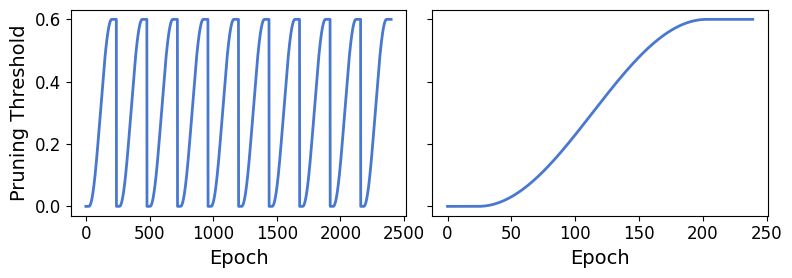

In [11]:
PRUNING_WEIGHT_THRESHOLD = 0.6 #Threshold for 10D Lorenz 96 model. Uses linear prune schedule
N_PERIODS = 10
PRUNING_EPOCHS_PER_PERIOD = 240
NUM_EPOCHS = PRUNING_EPOCHS_PER_PERIOD * N_PERIODS

import pruning_schedule as ps

# Define the pruning schedule

pruning_schedule = ps.pruning_schedule_ramp(maximum_threshold=PRUNING_WEIGHT_THRESHOLD, 
                                                    steps_per_period=PRUNING_EPOCHS_PER_PERIOD, 
                                                    num_periods=N_PERIODS, 
                                                    zero_percentage=0.1,
                                                    show_plot=True)

### Training

In [12]:
#Setup
callbacks = []

EARLY_STOPPING_LOSS_THRESHOLD = 1e-8  # Threshold for early stopping (Layer Based)
EARLY_STOPPING_PRUNING_THRESHOLD = 0.4

training_histories = []
weights_list = []

In [13]:
#change 0 to a other number if you want to start training from other dimensions
for i in range(0, 3):
    print(f"Training dimension {i + 1}...")
    
    reinitialize_model_weights(model)
    output = training_output[:, i:i+1]

    history = SREINet_fit_w_pruning(
        model,                   # Model to train
        training_input,             # Input data for training
        output,                     # Output data for training
        batch_size=MINI_BATCH_SIZE, # Number of samples per gradient update
        validation_split=0.0,      # Fraction of the training data to be used as validation data
        epochs=round(NUM_EPOCHS),   # Number of times the entire training dataset is passed through the model
        optimizer=my_optimizer,     # Optimizer to use for training
        pruning_schedule = pruning_schedule, # Pruning schedule for gradually increasing the sparsity level
        loss_fn=loss_fn,            # Loss function to use for training
        data_type=MY_DATA_TYPE,     # Data type to use for training
        callbacks= callbacks,       # List of callbacks to apply during training
        early_stopping_loss_threshold=EARLY_STOPPING_LOSS_THRESHOLD,# Threshold for early stopping (Layer Based)
        early_stopping_pruning_threshold=EARLY_STOPPING_PRUNING_THRESHOLD, # Threshold for early stopping (Pruning Based)
        verbose=1,                   # Hide the epoch steps
        print_every=20,
    )
    
    training_histories.append(history)

    # Retrieve the weights of the trained model
    weights_list.append([model.get_layer('SREINet').get_weights()])
   

Training dimension 1...
Epoch  20:  Train Loss: 2.6321e+00,  Validation Loss: 0.0000e+00,  Epoch Time: 0.07s,  Current Pruning Threshold: 0
Epoch  40:  Train Loss: 6.6887e-04,  Validation Loss: 0.0000e+00,  Epoch Time: 0.07s,  Current Pruning Threshold: 0.010336
Epoch  60:  Train Loss: 3.4701e-03,  Validation Loss: 0.0000e+00,  Epoch Time: 0.07s,  Current Pruning Threshold: 0.054843
Epoch  80:  Train Loss: 1.4346e-05,  Validation Loss: 0.0000e+00,  Epoch Time: 0.07s,  Current Pruning Threshold: 0.12925
Epoch 100:  Train Loss: 1.9834e-06,  Validation Loss: 0.0000e+00,  Epoch Time: 0.07s,  Current Pruning Threshold: 0.22448
Epoch 120:  Train Loss: 2.1748e-06,  Validation Loss: 0.0000e+00,  Epoch Time: 0.07s,  Current Pruning Threshold: 0.32891
Epoch 140:  Train Loss: 2.0813e-06,  Validation Loss: 0.0000e+00,  Epoch Time: 0.07s,  Current Pruning Threshold: 0.42983
Early stopping at epoch 145 as train loss 0.000000000051 is below the threshold 0.000000010000
Traininng Stopped. Time elapsed

### Last three dimensions

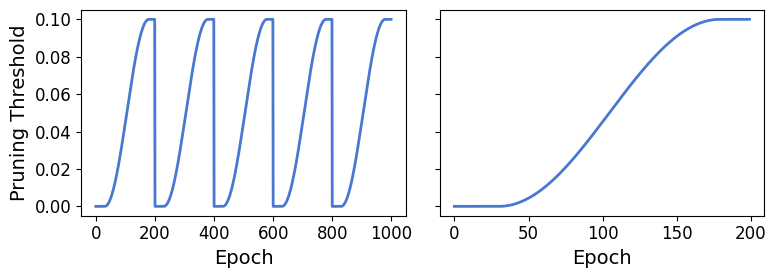

In [14]:
PRUNING_WEIGHT_THRESHOLD = 0.1 #Threshold for 10D Lorenz 96 model. Uses linear prune schedule
N_PERIODS = 5
PRUNING_EPOCHS_PER_PERIOD = 200
NUM_EPOCHS = PRUNING_EPOCHS_PER_PERIOD * N_PERIODS

import pruning_schedule as ps

# Define the pruning schedule

pruning_schedule = ps.pruning_schedule_ramp(maximum_threshold=PRUNING_WEIGHT_THRESHOLD, 
                                                    steps_per_period=PRUNING_EPOCHS_PER_PERIOD, 
                                                    num_periods=N_PERIODS, 
                                                    zero_percentage=0.15,
                                                    show_plot=True)

In [15]:
#Setup
callbacks = []

EARLY_STOPPING_LOSS_THRESHOLD = 2e-1  # Threshold for early stopping (Layer Based)
EARLY_STOPPING_PRUNING_THRESHOLD = 0.05



In [16]:
#change 0 to a other number if you want to start training from other dimensions
for i in range(3, training_output.shape[1]):
    print(f"Training dimension {i + 1}...")
    
    reinitialize_model_weights(model)
    output = training_output[:, i:i+1]

    history = SREINet_fit_w_pruning(
        model,                   # Model to train
        training_input,             # Input data for training
        output,                     # Output data for training
        batch_size=MINI_BATCH_SIZE, # Number of samples per gradient update
        validation_split=0.0,      # Fraction of the training data to be used as validation data
        epochs=round(NUM_EPOCHS),   # Number of times the entire training dataset is passed through the model
        optimizer=my_optimizer,     # Optimizer to use for training
        pruning_schedule = pruning_schedule, # Pruning schedule for gradually increasing the sparsity level
        loss_fn=loss_fn,            # Loss function to use for training
        data_type=MY_DATA_TYPE,     # Data type to use for training
        callbacks= callbacks,       # List of callbacks to apply during training
        early_stopping_loss_threshold=EARLY_STOPPING_LOSS_THRESHOLD,# Threshold for early stopping (Layer Based)
        early_stopping_pruning_threshold=EARLY_STOPPING_PRUNING_THRESHOLD, # Threshold for early stopping (Pruning Based)
        verbose=1,                   # Hide the epoch steps
        print_every=20,
        external_mask_indices=None,
        external_mask_updates=None,
    )
    
    training_histories.append(history)

    # Retrieve the weights of the trained model
    weights_list.append([model.get_layer('SREINet').get_weights()])
   

Training dimension 4...
Epoch  20:  Train Loss: 4.9441e+00,  Validation Loss: 0.0000e+00,  Epoch Time: 0.07s,  Current Pruning Threshold: 0
Epoch  40:  Train Loss: 2.7616e+00,  Validation Loss: 0.0000e+00,  Epoch Time: 0.07s,  Current Pruning Threshold: 0.00089753
Epoch  60:  Train Loss: 1.0331e+00,  Validation Loss: 0.0000e+00,  Epoch Time: 0.07s,  Current Pruning Threshold: 0.0090592
Epoch  80:  Train Loss: 6.6924e-01,  Validation Loss: 0.0000e+00,  Epoch Time: 0.07s,  Current Pruning Threshold: 0.024394
Epoch 100:  Train Loss: 5.2816e-01,  Validation Loss: 0.0000e+00,  Epoch Time: 0.07s,  Current Pruning Threshold: 0.044215
Epoch 120:  Train Loss: 5.6212e-01,  Validation Loss: 0.0000e+00,  Epoch Time: 0.07s,  Current Pruning Threshold: 0.065049
Epoch 140:  Train Loss: 5.6737e-01,  Validation Loss: 0.0000e+00,  Epoch Time: 0.07s,  Current Pruning Threshold: 0.083247
Epoch 160:  Train Loss: 6.4223e-01,  Validation Loss: 0.0000e+00,  Epoch Time: 0.07s,  Current Pruning Threshold: 0.095

## **IV. Coefficient Reconstructor (SREINet)**

#### `generate_set_labels`

In [17]:
def generate_set_labels(N):
    num_terms = N // 5

    return ['Constant'] + [f'x{i}' for i in range(1, num_terms+1)] + [f'cos(x{i})' for i in range(1, num_terms+1)] + [f'sin(x{i})' for i in range(1, num_terms+1)] + [f'cos(2*x{i})' for i in range(1, num_terms+1)] + [f'sin(2*x{i})' for i in range(1, num_terms+1)]


#### `coefficient_reconstruction`

In [18]:
def coefficient_reconstruction(dim_index,
                             weights, 
                             normalizer=None,  # Add normalizer parameter
                             minimum_coefficient_threshold = 1e-1,
                             coefficient_output_digits = 10, 
                             enable_coefficient_sorting = False):
    
    max_neurons = max(max(len(layer) for layer in SREINet) for SREINet in weights)
    labels = generate_set_labels(max_neurons - 1)

    def explore_path(SREINet_index, layer, neuron, weight_product, label_counts, non_zero_paths):
        if layer == len(weights[SREINet_index]) - 1:
            non_zero_paths.append((label_counts, weight_product))
            return

        for next_neuron, weight in enumerate(weights[SREINet_index][layer][neuron]):
            if abs(weight) <= 1e-15:
                continue  
            new_weight_product = weight_product * weight
            next_label_counts = label_counts.copy()
            next_label_counts[labels[next_neuron]] = next_label_counts.get(labels[next_neuron], 0) + 1
            explore_path(SREINet_index, layer + 1, next_neuron, new_weight_product, next_label_counts, non_zero_paths)
    
    # Rest of the code remains the same
    all_SREINet_products = []
    for SREINet_index, _ in enumerate(weights):
        non_zero_paths = []
        for neuron_index in range(len(weights[SREINet_index][0])):
            label_counts = {labels[neuron_index]: 1}
            explore_path(SREINet_index, 0, neuron_index, 1, label_counts, non_zero_paths)
        
        SREINet_products = {}
        for label_counts, weight_product in non_zero_paths:
            label_counts_key = frozenset(label_counts.items())
            if label_counts_key in SREINet_products:
                SREINet_products[label_counts_key] += weight_product
            else:
                SREINet_products[label_counts_key] = weight_product

        #scale the weight_product by the normalizer
        if normalizer is not None:
            SREINet_products = {k: v * normalizer[dim_index] for k, v in SREINet_products.items()}
        
        SREINet_products = {k: v for k, v in SREINet_products.items() if abs(v) >= minimum_coefficient_threshold}
        
        if enable_coefficient_sorting:
            sorted_SREINet_products = dict(sorted(SREINet_products.items(), key=lambda item: abs(item[1]), reverse=True))
        else:
            sorted_SREINet_products = SREINet_products

        all_SREINet_products.append(sorted_SREINet_products)

    # Output formatting remains the same
    labeled_all_SREINet_products = []
    for SREINet_index, sorted_SREINet_products in enumerate(all_SREINet_products):
        SREINet_product_strings = []
        for key, value in sorted_SREINet_products.items():
            labels_list = []
            only_constant = len(key) == 1 and any(label == 'Constant' for label, _ in key)
            
            for label, count in sorted(key):
                if label == 'Constant' and len(key) > 1:
                    continue
                if label != 'Constant' and count > 1:
                    labels_list.append(f"{label}^{count}")
                elif label == 'Constant' or count == 1:
                    labels_list.append(label if label != 'Constant' else '')
            
            label_str = '*'.join(filter(None, labels_list))

            # Apply normalizer if provided
            #if normalizer is not None:
            #    value = value * normalizer[dim_index]

            formatted_value = f"{abs(value):.{coefficient_output_digits}g}"

            term_str = label_str if formatted_value == '1' else f"{formatted_value}*{label_str}" if not only_constant else formatted_value if formatted_value != '1' else ''
            sign = '+' if value >= 0 else '-'
            if SREINet_product_strings or value < 0:
                term_str = f" {sign} {term_str}"
            else:
                term_str = term_str
            SREINet_product_strings.append(term_str)

        formatted_output = ''.join(SREINet_product_strings)
        if formatted_output == '':
            formatted_output = '0'
        layer_prefix = f"(x{SREINet_index+dim_index+1})'= "
        full_output = layer_prefix + formatted_output
        labeled_all_SREINet_products.append(full_output)

    return labeled_all_SREINet_products

## **V. Results**
### **Identified Model**

In [19]:
all_strings = []

for i in range(len(weights_list)):
    path_products = coefficient_reconstruction(
        i, weights_list[i], 
        normalizer=None,
        minimum_coefficient_threshold=5e-2,
        coefficient_output_digits=10, 
        enable_coefficient_sorting=False
    )
    
    for index, dimension in enumerate(path_products):
        all_strings.append(f"{dimension}")

# Join all strings with newlines (or any separator you like)
ode_string = "\n".join(all_strings)
print(ode_string)

(x1)'= 1.000000175*x4
(x2)'= 1.000000023*x5
(x3)'= 0.9999999918*x6
(x4)'= 0.05854674771*sin(x1) + 0.1637597983*sin(x1)*x1 + 0.1925324178*sin(x1)*x2 + 0.1070313528*sin(x1)*x3 - 0.5721824414*cos(x1)*sin(x1) - 0.894073248*cos(x2)*sin(x1) + 0.5024891116*sin(x1)^2 - 0.2276646993*sin(x1)*sin(x2) + 0.1975329939*sin(x1)*sin(x3) + 1.69736897*cos(2*x1)*sin(x1) + 4.679891646*cos(2*x2)*sin(x1) + 0.4766280456*cos(2*x3)*sin(x1) + 0.2131252699*cos(x1)*sin(x2) + 0.09958402543*cos(x2)*sin(x2) + 0.1917538566*sin(x2)^2 + 0.07188599605*sin(x2)*sin(x3) - 0.8761636635*cos(2*x1)*sin(x2) - 0.8604159082*cos(2*x2)*sin(x2) - 0.1697118536*cos(2*x3)*sin(x2) - 0.1218553858*sin(2*x3)*sin(x2) + 0.9093349153*cos(2*x5)*sin(x1) - 0.5741342678*cos(2*x5)*sin(x2) + 0.1458728697*sin(2*x1)*x5 - 0.4956140838*sin(2*x1)*sin(x1) + 1.480502122*cos(2*x1)*sin(2*x1) + 0.774083215*cos(2*x2)*sin(2*x1) - 0.4821033515*sin(2*x1)*sin(2*x2) + 0.6545523637*sin(2*x1)*sin(2*x4) + 0.5820372804*cos(x1)*cos(x6)*x1 + 0.3712464006*cos(x3)*cos(x6)*